# Link prediction: model search and submissions

Follows on from `link-prediction-original.ipynb`, which built the leakage-free training set and the 36 features and compared five tuned models. This notebook repeats none of that analysis. It loads the exported features, tries a wider range of models and optimisations, ranks them all on one shared protocol, and writes a submission file for each of the best.

**What we take from the original notebook**
- Training pairs: 6377 held-out edges and 6377 uniform non-edges from a 20-fold edge hold-out. The `fold` column says which graph a pair was scored on, so cross-validation must be grouped by it.
- Features: 36 in five groups (node, neighbourhood, path, community, attribute), plus an 18-feature `selected` subset. Community and path features carry most of the signal.
- Final model: soft voting of a random forest, logistic regression and gradient boosting. Grouped CV accuracy 0.875; shift-aware pseudo-test 0.878 ± 0.011. All good models were within about one standard error of each other, so **the data, not the model, sets the ceiling**. Gains here will be small at best. The aim is a handful of strong submissions that differ slightly.
- If the "top half" decision rule is used, ties must be broken at random, because the training rows are sorted by label.

**Inputs** (`../output/features/`): `train_features.csv`, `test_features.csv`, `feature_groups.json`.
**Outputs** (`../output/submissions/`): `NN_<model>.csv` for each kept model (`ID,prediction`, ranked by cross-validated accuracy) and `leaderboard.csv` with every candidate. The original's `../output/submission.csv` is not touched.

**Outline**
1. Setup
2. Evaluation protocol
3. Baselines: the original notebook's models
4. More model families
5. Hyperparameter tuning
6. Optimisations: feature sets, monotone constraints, bagging, decision rule
7. Ensembles: averaging and stacking
8. Leaderboard and selection
9. Submissions

Summary

## 1. Setup

In [1]:
import json
import re
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from scipy.special import logit
from scipy.stats import loguniform, randint, uniform
from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.ensemble import (AdaBoostClassifier, BaggingClassifier, ExtraTreesClassifier,
                              HistGradientBoostingClassifier, RandomForestClassifier, VotingClassifier)
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import GroupKFold, RandomizedSearchCV
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import QuantileTransformer, SplineTransformer, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore', message='A worker stopped')   # joblib recycling a worker; harmless

SEED = 42
N_SPLITS = 5        # grouped CV splits over the 20 hold-out folds, as in the original
REPEATS = 3         # independent shuffles of those splits; every candidate is scored on the same ones
TUNE_SEED = 999     # hyperparameter search uses its own shuffle, not the evaluation splits
N_KEEP = 8          # submissions to write
MAX_PER_FAMILY = 2  # keeps the kept submissions varied
FEATURES_DIR = Path('../output/features')
SUBMISSIONS = Path('../output/submissions')
ORIGINAL_SUBMISSION = Path('../output/submission.csv')

In [2]:
# Plot style, same as the original notebook.
C = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4']
INK, INK2, MUTED, GRID = '#0b0b0b', '#52514e', '#898781', '#e1e0d9'
plt.rcParams.update({
    'figure.facecolor': '#fcfcfb', 'axes.facecolor': '#fcfcfb', 'savefig.facecolor': '#fcfcfb',
    'axes.edgecolor': '#c3c2b7', 'axes.labelcolor': INK2, 'text.color': INK,
    'xtick.color': MUTED, 'ytick.color': MUTED,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.6, 'axes.axisbelow': True,
    'axes.titlesize': 11, 'axes.titleweight': 'bold', 'axes.titlelocation': 'left',
    'font.size': 9, 'lines.linewidth': 2, 'legend.frameon': False, 'figure.dpi': 110,
})

In [3]:
train = pd.read_csv(FEATURES_DIR / 'train_features.csv')
test = pd.read_csv(FEATURES_DIR / 'test_features.csv')
meta = json.loads((FEATURES_DIR / 'feature_groups.json').read_text())
FEATURE_GROUPS = meta['groups']
FEATURES = [f for fs in FEATURE_GROUPS.values() for f in fs]
FEATURE_SETS = {
    'all': FEATURES,
    'selected': meta['selected'],                                         # the original's selection rule (its section 7)
    'no attribute': [f for f in FEATURES if f not in meta['sensitive']],  # without the sensitive group
}
y = train.label.to_numpy()
groups = train.fold.to_numpy()

print(f'{len(train)} training pairs ({y.mean():.0%} links, {train.fold.nunique()} hold-out folds), {len(test)} test pairs')
print('features per set:', {name: len(cols) for name, cols in FEATURE_SETS.items()})

12754 training pairs (50% links, 20 hold-out folds), 1416 test pairs
features per set: {'all': 36, 'selected': 18, 'no attribute': 32}


## 2. Evaluation protocol

The gaps between good models are a few tenths of a point (original, section 10), about the size of the noise from how the folds happen to be split. So every candidate is scored the same way, on the same splits:

- **Repeated grouped CV.** `GroupKFold` with 5 splits over the 20 hold-out folds (pairs scored on the same graph stay on the same side), shuffled with 3 different seeds. That gives 15 validation folds, each exactly balanced, and every candidate sees the same 15.
- **Out-of-fold (OOF) probabilities are stored.** Each training pair gets one probability per repeat from a model that never saw its hold-out fold. The ensembles and decision rules in sections 6–7 are built from these stored probabilities.
- **Ranking metric:** accuracy at the 0.5 cut-off, averaged over the 15 validation folds. We also report ROC-AUC, and the paired difference to the original's final model with a standard error. The three repeats reuse the same pairs, so that standard error divides by √5, not √15. It is only a rough guide.

We do not rerun the shift-aware pseudo-test: the original showed that grouped CV agrees with it to within 0.6 points for every model (its section 10). Hyperparameters are tuned on a fourth, separate shuffle (`TUNE_SEED`). It still uses the same pairs, so tuned models are very slightly favoured in the ranking.

In [4]:
EVAL_SPLITS = [list(GroupKFold(N_SPLITS, shuffle=True, random_state=SEED + r).split(train, y, groups))
               for r in range(REPEATS)]
TUNE_CV = GroupKFold(N_SPLITS, shuffle=True, random_state=TUNE_SEED)
LECTURE_FAMILIES = {'logistic regression', 'k-NN', 'decision tree', 'random forest', 'gradient boosting'}


def top_half(scores, seed=SEED):
    """Label the highest-scoring half of the pairs as links (test and validation folds are exactly balanced).

    Ties are broken at random, never by row order: training rows are sorted by label, so an order-based
    tie-break would leak the labels."""
    scores = np.asarray(scores)
    order = np.lexsort((np.random.default_rng(seed).random(len(scores)), -scores))
    pred = np.zeros(len(scores), dtype=int)
    pred[order[: len(scores) // 2]] = 1
    return pred


def decide(scores, rule='0.5'):
    """0/1 predictions from link probabilities."""
    return top_half(scores) if rule == 'top half' else (np.asarray(scores) >= 0.5).astype(int)


def oof_scores(model, cols):
    """Out-of-fold link probabilities on the shared evaluation splits, shape (REPEATS, n_pairs)."""
    X = train[cols]
    jobs = [(r, tr, va) for r in range(REPEATS) for tr, va in EVAL_SPLITS[r]]
    fit_predict = lambda tr, va: clone(model).fit(X.iloc[tr], y[tr]).predict_proba(X.iloc[va])[:, 1]
    probas = Parallel(n_jobs=-1)(delayed(fit_predict)(tr, va) for _, tr, va in jobs)
    oof = np.empty((REPEATS, len(train)))
    for (r, _, va), p in zip(jobs, probas):
        oof[r, va] = p
    return oof


def fold_accuracies(oof, rule='0.5'):
    """Accuracy on each of the REPEATS x N_SPLITS validation folds."""
    return np.array([accuracy_score(y[va], decide(oof[r, va], rule)) for r in range(REPEATS) for _, va in EVAL_SPLITS[r]])

Every candidate goes into one registry. A candidate is a fitted-model recipe, an average of other candidates, a stacked model, or another decision rule on top of an existing candidate. Each one keeps its OOF probabilities, for ranking, and a function that produces its test probabilities. That function is only called for the candidates we keep (section 9).

In [5]:
CANDIDATES = {}    # name -> OOF probabilities, metadata and a recipe for test probabilities
TEST_PROBA = {}    # cache: name -> test probabilities


def register(name, oof, family, stage, features, lecture, test_fn, rule='0.5', model=None):
    accs = fold_accuracies(oof, rule)
    auc = np.mean([roc_auc_score(y, o) for o in oof])
    CANDIDATES[name] = dict(oof=oof, family=family, stage=stage, features=features, lecture=lecture,
                            test_fn=test_fn, rule=rule, model=model, accs=accs, auc=auc)
    print(f'{name:<52} accuracy {accs.mean():.4f}   AUC {auc:.4f}')


def test_proba(name):
    """Test link probabilities of a candidate (computed once)."""
    if name not in TEST_PROBA:
        TEST_PROBA[name] = CANDIDATES[name]['test_fn']()
    return TEST_PROBA[name]


def add_model(name, model, family, stage, features='all', lecture=None):
    """Score a model on the shared splits; its test probabilities come from a refit on all training pairs."""
    cols = FEATURE_SETS[features]
    test_fn = lambda: clone(model).fit(train[cols], y).predict_proba(test[cols])[:, 1]
    lecture = family in LECTURE_FAMILIES if lecture is None else lecture
    register(name, oof_scores(model, cols), family, stage, features, lecture, test_fn, model=model)


def readable(params):
    """Hyperparameters as a short string."""
    show = lambda v: type(v).__name__ if hasattr(v, 'fit') else (f'{v:.3g}' if isinstance(v, float) else v)
    return ', '.join(f"{k.split('__')[-1]}={show(v)}" for k, v in params.items())

## 3. Baselines: the original notebook's models

The five tuned models from the original's section 9 (all features), and its final soft-voting ensemble. The ensemble is the reference row of the leaderboard. Refitting it here must give back `../output/submission.csv` exactly.

In [6]:
ORIGINAL = {
    'logistic regression': make_pipeline(StandardScaler(), LogisticRegression(C=1, max_iter=5000)),
    'k-NN': make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=31, weights='distance')),
    'decision tree': DecisionTreeClassifier(max_depth=5, min_samples_leaf=20, random_state=SEED),
    'random forest': RandomForestClassifier(n_estimators=300, max_features='sqrt', min_samples_leaf=20, random_state=SEED),
    'gradient boosting': HistGradientBoostingClassifier(learning_rate=0.05, max_leaf_nodes=15, min_samples_leaf=20,
                                                         max_iter=300, random_state=SEED),
}
BASELINE = 'original final: soft vote RF + LR + GB'

t0 = time.time()
for family, model in ORIGINAL.items():
    add_model(f'{family} (original)', model, family, 'original')
add_model(BASELINE, VotingClassifier([(m, ORIGINAL[m]) for m in ['random forest', 'logistic regression', 'gradient boosting']],
                                     voting='soft'), 'ensemble', 'original', lecture=True)
print(f'{time.time() - t0:.0f}s')

original_pred = pd.read_csv(ORIGINAL_SUBMISSION).set_index('ID').loc[test.ID, 'prediction'].to_numpy()
print(f'\nrefit of the baseline vs ../output/submission.csv: {(decide(test_proba(BASELINE)) == original_pred).mean():.3f} agreement')

logistic regression (original)                       accuracy 0.8732   AUC 0.9332


k-NN (original)                                      accuracy 0.8693   AUC 0.9274
decision tree (original)                             accuracy 0.8674   AUC 0.9262


random forest (original)                             accuracy 0.8738   AUC 0.9354


gradient boosting (original)                         accuracy 0.8745   AUC 0.9361


original final: soft vote RF + LR + GB               accuracy 0.8746   AUC 0.9369
18s



refit of the baseline vs ../output/submission.csv: 1.000 agreement


## 4. More model families

Untuned, sensible defaults first, to see which families are worth tuning. Models that need scaled inputs get a quantile transform to a normal distribution, which tames the heavy-tailed counts (degrees, path counts).

- **Extra trees**: a random forest that also draws the split thresholds at random.
- **AdaBoost**: the classic boosting algorithm, here with decision stumps.
- **SVM** with an RBF kernel (its scores are turned into probabilities with Platt scaling on an internal 5-fold split), and a small **neural network** (two hidden layers, early stopping).
- **Naive Bayes, LDA and QDA**: simple generative baselines.
- **Logistic regression on splines**: every feature expanded into a smooth piecewise curve, so the model is non-linear but still additive and readable, much like a generalised additive model.

The leaderboard's `lecture method` column marks the five families the original notebook used as methods from the lectures (and ensembles built only from them). Check whether the others were covered before using one in the report.

In [7]:
qt = lambda: QuantileTransformer(output_distribution='normal', random_state=SEED)
MORE = {
    'extra trees': ('extra trees', ExtraTreesClassifier(n_estimators=500, min_samples_leaf=10, random_state=SEED)),
    'AdaBoost': ('AdaBoost', AdaBoostClassifier(n_estimators=300, random_state=SEED)),
    'SVM (RBF)': ('SVM', make_pipeline(qt(), CalibratedClassifierCV(SVC(), ensemble=False))),
    'neural network': ('neural network', make_pipeline(qt(), MLPClassifier((64, 32), alpha=1e-3, early_stopping=True,
                                                                           max_iter=1000, random_state=SEED))),
    'naive Bayes': ('naive Bayes', make_pipeline(qt(), GaussianNB())),
    'LDA': ('LDA', make_pipeline(qt(), LinearDiscriminantAnalysis())),
    'QDA': ('QDA', make_pipeline(qt(), QuadraticDiscriminantAnalysis(reg_param=0.1))),
    'logistic regression on splines': ('logistic regression', make_pipeline(qt(), SplineTransformer(n_knots=5),
                                                                            LogisticRegression(C=0.1, max_iter=5000))),
}
t0 = time.time()
for name, (family, model) in MORE.items():
    add_model(f'{name} (default)', model, family, 'default')
print(f'{time.time() - t0:.0f}s')

extra trees (default)                                accuracy 0.8728   AUC 0.9348


AdaBoost (default)                                   accuracy 0.8709   AUC 0.9333


SVM (RBF) (default)                                  accuracy 0.8653   AUC 0.9201


neural network (default)                             accuracy 0.8703   AUC 0.9331


naive Bayes (default)                                accuracy 0.7821   AUC 0.9084


LDA (default)                                        accuracy 0.8663   AUC 0.9287


QDA (default)                                        accuracy 0.8530   AUC 0.9177


logistic regression on splines (default)             accuracy 0.8739   AUC 0.9358
31s


## 5. Hyperparameter tuning

Randomised search over wide ranges for every family that is competitive at its defaults. The original used a small grid, so it may have missed better settings. Two choices differ from the original:
- **Search on the separate tuning shuffle**, so the evaluation splits stay untouched (section 2).
- **Pick by log loss, not accuracy.** Accuracy only changes when a pair's probability crosses 0.5, so nearby settings often tie or differ by chance. Log loss uses the whole probability. The leaderboard still ranks by accuracy.

In [8]:
SEARCH = {   # family name -> (model family, estimator, search space, number of settings tried)
    'logistic regression': ('logistic regression', Pipeline([('scale', StandardScaler()), ('clf', LogisticRegression(max_iter=5000))]),
        {'scale': [StandardScaler(), qt()], 'clf__C': loguniform(1e-3, 1e2)}, 20),
    'logistic regression on splines': ('logistic regression',
        Pipeline([('scale', qt()), ('spline', SplineTransformer()), ('clf', LogisticRegression(max_iter=5000))]),
        {'spline__n_knots': randint(3, 10), 'spline__degree': [2, 3], 'clf__C': loguniform(1e-3, 10)}, 25),
    'k-NN': ('k-NN', Pipeline([('scale', StandardScaler()), ('clf', KNeighborsClassifier())]),
        {'scale': [StandardScaler(), qt()], 'clf__n_neighbors': randint(10, 250), 'clf__weights': ['uniform', 'distance']}, 25),
    'random forest': ('random forest', RandomForestClassifier(n_estimators=500, random_state=SEED),
        {'max_features': ['sqrt', 0.1, 0.2, 0.3, 0.5], 'min_samples_leaf': randint(1, 60), 'max_depth': [None, 8, 12, 20]}, 25),
    'extra trees': ('extra trees', ExtraTreesClassifier(n_estimators=500, random_state=SEED),
        {'max_features': ['sqrt', 0.2, 0.3, 0.5, 0.8], 'min_samples_leaf': randint(1, 60), 'max_depth': [None, 8, 12, 20]}, 25),
    'gradient boosting': ('gradient boosting', HistGradientBoostingClassifier(random_state=SEED),
        {'learning_rate': loguniform(0.01, 0.2), 'max_iter': randint(100, 800), 'max_leaf_nodes': randint(4, 48),
         'min_samples_leaf': randint(10, 150), 'l2_regularization': loguniform(1e-3, 10), 'max_features': uniform(0.3, 0.7),
         'early_stopping': [True, False]}, 40),
    'SVM (RBF)': ('SVM', Pipeline([('scale', qt()), ('clf', CalibratedClassifierCV(SVC(), ensemble=False))]),
        {'scale': [StandardScaler(), qt()], 'clf__estimator__C': loguniform(0.05, 10), 'clf__estimator__gamma': loguniform(3e-3, 0.3)}, 15),
    'neural network': ('neural network',
        Pipeline([('scale', qt()), ('clf', MLPClassifier(early_stopping=True, max_iter=1000, random_state=SEED))]),
        {'clf__hidden_layer_sizes': [(32,), (64,), (64, 32), (128, 64)], 'clf__alpha': loguniform(1e-5, 1e-1),
         'clf__learning_rate_init': loguniform(3e-4, 3e-3)}, 20),
}

TUNED, tuning_rows = {}, []
t0 = time.time()
for name, (family, estimator, space, n_iter) in SEARCH.items():
    search = RandomizedSearchCV(estimator, space, n_iter=n_iter, cv=TUNE_CV, n_jobs=-1, random_state=SEED, refit=False,
                                scoring={'log_loss': 'neg_log_loss', 'accuracy': 'accuracy'})
    search.fit(train[FEATURES], y, groups=groups)
    res = search.cv_results_
    i = np.argmax(res['mean_test_log_loss'])
    TUNED[name] = clone(estimator).set_params(**res['params'][i])
    tuning_rows.append({'model': name, 'settings tried': n_iter, 'log loss': -res['mean_test_log_loss'][i],
                        'accuracy (tuning split)': res['mean_test_accuracy'][i], 'best settings': readable(res['params'][i])})
print(f'search: {time.time() - t0:.0f}s')
pd.set_option('display.max_colwidth', 120)
pd.DataFrame(tuning_rows).set_index('model').round(4)

search: 387s


,settings tried,log loss,accuracy (tuning split),best settings
model,,,,
logistic regression,20,0.3252,0.8725,"C=0.421, scale=StandardScaler"
logistic regression on splines,25,0.3162,0.8739,"C=1.38, degree=2, n_knots=6"
k-NN,25,0.3350,0.8661,"n_neighbors=199, weights=distance, scale=StandardScaler"
random forest,25,0.3192,0.8742,"max_depth=8, max_features=0.5, min_samples_leaf=2"
extra trees,25,0.3196,0.8738,"max_depth=12, max_features=0.8, min_samples_leaf=9"
gradient boosting,40,0.3163,0.8758,"early_stopping=False, l2_regularization=0.0115, learning_rate=0.0208, max_features=0.981, max_iter=464, max_leaf_nod..."
SVM (RBF),15,0.3515,0.8709,"C=9.15, gamma=0.0257, scale=StandardScaler"
neural network,20,0.3223,0.8726,"alpha=1.21e-05, hidden_layer_sizes=(64,), learning_rate_init=0.00158"


The tuned settings, scored on the shared evaluation splits:

In [9]:
t0 = time.time()
for name, model in TUNED.items():
    add_model(f'{name} (tuned)', model, SEARCH[name][0], 'tuned')
print(f'{time.time() - t0:.0f}s')

logistic regression (tuned)                          accuracy 0.8731   AUC 0.9332


logistic regression on splines (tuned)               accuracy 0.8737   AUC 0.9370


k-NN (tuned)                                         accuracy 0.8661   AUC 0.9296


random forest (tuned)                                accuracy 0.8743   AUC 0.9356


extra trees (tuned)                                  accuracy 0.8740   AUC 0.9355


gradient boosting (tuned)                            accuracy 0.8753   AUC 0.9367


SVM (RBF) (tuned)                                    accuracy 0.8716   AUC 0.9177


neural network (tuned)                               accuracy 0.8698   AUC 0.9337
97s


## 6. Optimisations

Four changes that do not alter a model's family, each applied to the best tuned models.

### 6.1 Feature sets

The three best tuned models on the 18 `selected` features and on all features except the sensitive attribute group. In the original, the selected subset never beat all 36 features, and dropping the attribute features changed nothing because community features carry the same signal (its sections 6.5 and 12).

In [10]:
def best(stage, k=1, exclude_families=()):
    """Names of the k most accurate candidates of a stage."""
    names = [n for n, c in CANDIDATES.items() if c['stage'] == stage and c['family'] not in exclude_families]
    return sorted(names, key=lambda n: -CANDIDATES[n]['accs'].mean())[:k]


top_tuned = best('tuned', k=3)
t0 = time.time()
for name in top_tuned:
    c = CANDIDATES[name]
    for features in ['selected', 'no attribute']:
        add_model(name.replace('(tuned)', f'(tuned, {features})'), c['model'], c['family'], 'feature set', features)
print(f'{time.time() - t0:.0f}s')

gradient boosting (tuned, selected)                  accuracy 0.8728   AUC 0.9340


gradient boosting (tuned, no attribute)              accuracy 0.8742   AUC 0.9365


random forest (tuned, selected)                      accuracy 0.8726   AUC 0.9318


random forest (tuned, no attribute)                  accuracy 0.8740   AUC 0.9352


extra trees (tuned, selected)                        accuracy 0.8723   AUC 0.9328


extra trees (tuned, no attribute)                    accuracy 0.8731   AUC 0.9355
98s


### 6.2 Monotone constraints for gradient boosting

For every proximity score (neighbourhood, path, community and attribute groups), a pair that is closer should never be *less* likely to be a link. A boosted model can still learn small wiggles that break this rule, and wiggles fitted to noise generalise badly. `monotonic_cst` forbids them. `shortest_path` gets a decreasing constraint and all other proximity scores an increasing one. `pref_attach` is a degree product, not a proximity score, so it stays free like the node features.

We set the directions by reasoning, not from the data. The assertion checks them against each feature's univariate AUC.

In [11]:
PROXIMITY = [f for g in ('neighbourhood', 'path', 'community', 'attribute') for f in FEATURE_GROUPS[g] if f != 'pref_attach']
direction = {f: -1 if f == 'shortest_path' else 1 for f in PROXIMITY}
assert all((roc_auc_score(y, train[f]) > 0.5) == (d == 1) for f, d in direction.items())
MONOTONE = [direction.get(f, 0) for f in FEATURES]   # a list in column order, so it also works inside BaggingClassifier

gb_tuned = TUNED['gradient boosting']
add_model('gradient boosting (tuned, monotone)', clone(gb_tuned).set_params(monotonic_cst=MONOTONE),
          'gradient boosting', 'monotone')
add_model('gradient boosting (original, monotone)', clone(ORIGINAL['gradient boosting']).set_params(monotonic_cst=MONOTONE),
          'gradient boosting', 'monotone')

gradient boosting (tuned, monotone)                  accuracy 0.8741   AUC 0.9369


gradient boosting (original, monotone)               accuracy 0.8735   AUC 0.9363


### 6.3 Bagging and seed averaging

Averaging several copies of a model fitted on resampled data (bagging), or with different random seeds, lowers the variance of its predictions:
- gradient boosting (tuned, and tuned with monotone constraints): 10 copies, each on a random 80% of the pairs;
- the neural network: 5 seeds on all pairs (the initial weights and the early-stopping split change).

In [12]:
bag = lambda model, n, frac, bootstrap: BaggingClassifier(model, n_estimators=n, max_samples=frac, bootstrap=bootstrap,
                                                         random_state=SEED)
t0 = time.time()
add_model('gradient boosting (tuned, bagged)', bag(gb_tuned, 10, 0.8, False), 'gradient boosting', 'bagging')
add_model('gradient boosting (tuned, monotone, bagged)',
          bag(clone(gb_tuned).set_params(monotonic_cst=MONOTONE), 10, 0.8, False), 'gradient boosting', 'bagging')
add_model('neural network (tuned, 5 seeds)', bag(TUNED['neural network'], 5, 1.0, False), 'neural network', 'bagging')
print(f'{time.time() - t0:.0f}s')

gradient boosting (tuned, bagged)                    accuracy 0.8757   AUC 0.9373


gradient boosting (tuned, monotone, bagged)          accuracy 0.8752   AUC 0.9374


neural network (tuned, 5 seeds)                      accuracy 0.8723   AUC 0.9350
136s


### 6.4 Decision rule

The test set is exactly 708 links and 708 non-links. Instead of cutting at 0.5, we can label the top half of the scores as links. That rule only needs the ranking to be right, so it is immune to a shift of all probabilities. In the original's pseudo-test, it was never better than 0.5 (its section 10). Here it is applied to the two best single models so far; every validation fold is exactly balanced, so the rule is applied per fold.

In [13]:
for name in sorted([n for n, c in CANDIDATES.items() if c['family'] != 'ensemble'], key=lambda n: -CANDIDATES[n]['accs'].mean())[:2]:
    c = CANDIDATES[name]
    register(f'{name} [top half]', c['oof'], c['family'], 'decision rule', c['features'], c['lecture'],
             (lambda n: lambda: test_proba(n))(name), rule='top half')

gradient boosting (tuned, bagged) [top half]         accuracy 0.8723   AUC 0.9373
gradient boosting (tuned) [top half]                 accuracy 0.8710   AUC 0.9367


## 7. Ensembles

Built from the stored OOF probabilities, so no extra fitting is needed to score them. The members are the best candidate of each family, using all features and the 0.5 rule, ranked by accuracy.
- **Soft vote**: the plain average of the members' probabilities, for the best 3 and the best 5 families.
- **Stacking**: logistic regression on the logits of the best 6 families' probabilities, which learns a weight for each member. It is scored with a second grouped CV on the same splits: within each repeat, the meta-model is fitted on the other folds' OOF probabilities. For the test pairs it is fitted on the OOF probabilities of all three repeats and applied to the members' test probabilities.

The original found that its ensemble members share most of their errors, so we do not expect averaging to add much.

In [14]:
def family_leaders():
    """Best single candidate per family (all features, 0.5 rule), most accurate first."""
    singles = [n for n, c in CANDIDATES.items()
               if c['family'] != 'ensemble' and c['features'] == 'all' and c['rule'] == '0.5']
    leaders = {}
    for n in sorted(singles, key=lambda n: -CANDIDATES[n]['accs'].mean()):
        leaders.setdefault(CANDIDATES[n]['family'], n)
    return list(leaders.values())


def add_soft_vote(name, members):
    oof = np.mean([CANDIDATES[m]['oof'] for m in members], axis=0)
    register(name, oof, 'ensemble', 'ensemble', 'all', all(CANDIDATES[m]['lecture'] for m in members),
             lambda: np.mean([test_proba(m) for m in members], axis=0))


def add_stack(name, members):
    z = lambda p: logit(np.clip(p, 1e-4, 1 - 1e-4))
    meta_model = LogisticRegression(max_iter=5000)
    oof = np.empty((REPEATS, len(train)))
    for r in range(REPEATS):
        Z = np.column_stack([z(CANDIDATES[m]['oof'][r]) for m in members])
        for tr, va in EVAL_SPLITS[r]:
            oof[r, va] = clone(meta_model).fit(Z[tr], y[tr]).predict_proba(Z[va])[:, 1]

    def test_fn():
        Z = np.vstack([np.column_stack([z(CANDIDATES[m]['oof'][r]) for m in members]) for r in range(REPEATS)])
        fitted = clone(meta_model).fit(Z, np.tile(y, REPEATS))
        print(f'{name} weights:', dict(zip(members, fitted.coef_[0].round(2))))
        return fitted.predict_proba(np.column_stack([z(test_proba(m)) for m in members]))[:, 1]

    register(name, oof, 'ensemble', 'ensemble', 'all', all(CANDIDATES[m]['lecture'] for m in members), test_fn)


leaders = family_leaders()
lecture_leaders = [n for n in leaders if CANDIDATES[n]['lecture']]
print('family leaders, best first:\n  ' + '\n  '.join(leaders) + '\n')
add_soft_vote('soft vote of the best 3 families', leaders[:3])
add_soft_vote('soft vote of the best 5 families', leaders[:5])
add_stack('stacking of the best 6 families', leaders[:6])
add_soft_vote('soft vote of the best 3 lecture families', lecture_leaders[:3])
print('\nlecture families in the last soft vote:', lecture_leaders[:3])

family leaders, best first:
  gradient boosting (tuned, bagged)
  random forest (tuned)
  extra trees (tuned)
  logistic regression on splines (default)
  neural network (tuned, 5 seeds)
  SVM (RBF) (tuned)
  AdaBoost (default)
  k-NN (original)
  decision tree (original)
  LDA (default)
  QDA (default)
  naive Bayes (default)

soft vote of the best 3 families                     accuracy 0.8755   AUC 0.9370
soft vote of the best 5 families                     accuracy 0.8752   AUC 0.9374
stacking of the best 6 families                      accuracy 0.8763   AUC 0.9376
soft vote of the best 3 lecture families             accuracy 0.8760   AUC 0.9376

lecture families in the last soft vote: ['gradient boosting (tuned, bagged)', 'random forest (tuned)', 'logistic regression on splines (default)']


## 8. Leaderboard and selection

Every candidate, ranked by accuracy. `vs original` is the paired difference to the original's final model on the same 15 validation folds, with its standard error (`s.e.`).

**Selection rule:** walk down the ranking and keep a candidate unless its family already has 2 kept, until 8 are kept. The original's final model is excluded, since it is already `../output/submission.csv`. The family cap keeps the submissions varied: otherwise most of them would be near-copies of one boosted model.

In [15]:
base_accs = CANDIDATES[BASELINE]['accs']
board = pd.DataFrame([{
    'model': name, 'family': c['family'], 'stage': c['stage'], 'features': c['features'], 'rule': c['rule'],
    'lecture method': c['lecture'], 'accuracy': c['accs'].mean(), 'AUC': c['auc'],
    'vs original': c['accs'].mean() - base_accs.mean(),
    's.e.': (c['accs'] - base_accs).std(ddof=1) / np.sqrt(N_SPLITS),
} for name, c in CANDIDATES.items()]).set_index('model').sort_values('accuracy', ascending=False)

kept, per_family = [], {}
for name, row in board.iterrows():
    if name != BASELINE and len(kept) < N_KEEP and per_family.get(row.family, 0) < MAX_PER_FAMILY:
        kept.append(name)
        per_family[row.family] = per_family.get(row.family, 0) + 1
board['kept'] = board.index.isin(kept)
print(f'{len(board)} candidates')
board.round(4)

39 candidates


,family,stage,features,rule,lecture method,accuracy,AUC,vs original,s.e.,kept
model,,,,,,,,,,
stacking of the best 6 families,ensemble,ensemble,all,0.5,False,0.8763,0.9376,0.0017,0.0007,True
soft vote of the best 3 lecture families,ensemble,ensemble,all,0.5,True,0.8760,0.9376,0.0014,0.0006,True
"gradient boosting (tuned, bagged)",gradient boosting,bagging,all,0.5,True,0.8757,0.9373,0.0011,0.0012,True
soft vote of the best 3 families,ensemble,ensemble,all,0.5,False,0.8755,0.9370,0.0009,0.0008,False
gradient boosting (tuned),gradient boosting,tuned,all,0.5,True,0.8753,0.9367,0.0007,0.0010,True
soft vote of the best 5 families,ensemble,ensemble,all,0.5,False,0.8752,0.9374,0.0006,0.0008,False
"gradient boosting (tuned, monotone, bagged)",gradient boosting,bagging,all,0.5,True,0.8752,0.9374,0.0005,0.0013,False
original final: soft vote RF + LR + GB,ensemble,original,all,0.5,True,0.8746,0.9369,0.0000,0.0000,False
gradient boosting (original),gradient boosting,original,all,0.5,True,0.8745,0.9361,-0.0001,0.0007,False


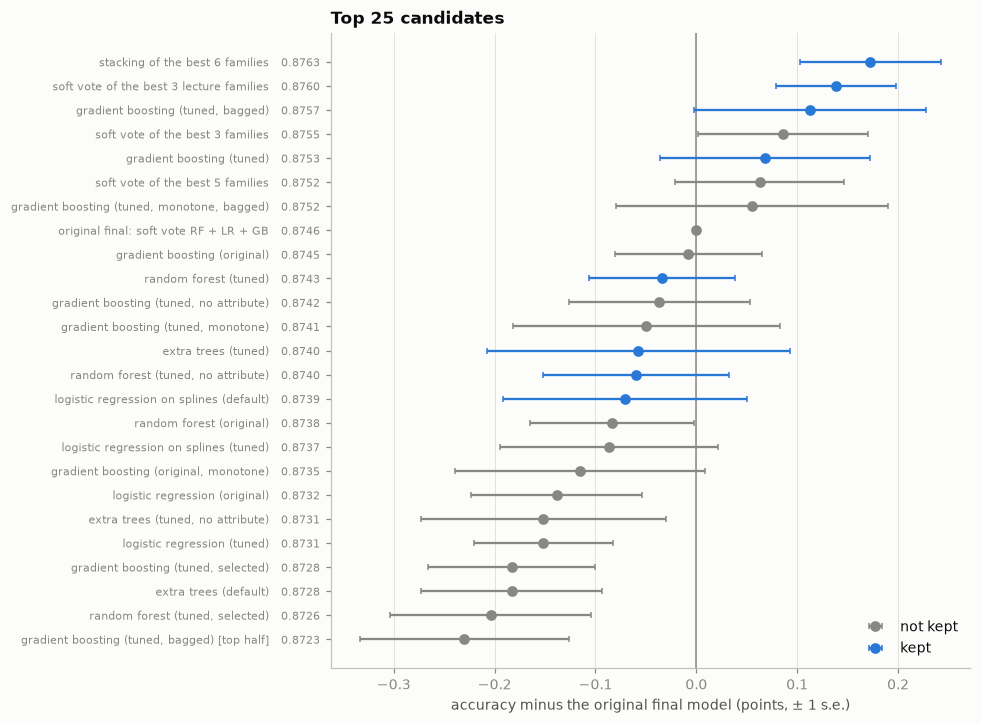

In [16]:
show = board.head(25).iloc[::-1]
yy = np.arange(len(show))
fig, ax = plt.subplots(figsize=(7.5, 7.5))
ax.axvline(0, color=MUTED, linewidth=1)
for is_kept, color, label in [(False, MUTED, 'not kept'), (True, C[0], 'kept')]:
    m = (show.kept == is_kept).to_numpy()
    ax.errorbar(show['vs original'][m] * 100, yy[m], xerr=show['s.e.'][m] * 100, fmt='o', ms=6, color=color,
                elinewidth=1.5, capsize=2, label=label)
ax.set_yticks(yy, [f'{n}   {a:.4f}' for n, a in zip(show.index, show.accuracy)], fontsize=7.5)
ax.grid(axis='y', visible=False)
ax.set(xlabel='accuracy minus the original final model (points, ± 1 s.e.)', title='Top 25 candidates')
ax.legend(loc='lower right')
plt.show()

## 9. Submissions

Every kept candidate is refitted on all 12754 training pairs and predicts the 1416 test pairs. Ensembles reuse their members' test probabilities. Old numbered files in `../output/submissions/` are removed first, so the folder always matches the current leaderboard.

In [17]:
SUBMISSIONS.mkdir(parents=True, exist_ok=True)
for old in SUBMISSIONS.glob('[0-9][0-9]_*.csv'):
    old.unlink()
slug = lambda s: re.sub(r'[^a-z0-9]+', '_', s.lower()).strip('_')
solution_ids = pd.read_csv('../input/solutionInput.csv').ID

t0 = time.time()
test_pred, files = {}, {}
for rank, name in enumerate(kept, 1):
    pred = decide(test_proba(name), CANDIDATES[name]['rule'])
    path = SUBMISSIONS / f'{rank:02d}_{slug(name)}.csv'
    pd.DataFrame({'ID': test.ID, 'prediction': pred}).to_csv(path, index=False)
    check = pd.read_csv(path)
    assert check.columns.tolist() == ['ID', 'prediction'] and check.ID.equals(solution_ids) and check.prediction.isin([0, 1]).all()
    test_pred[name], files[name] = pred, path.name
print(f'refits: {time.time() - t0:.0f}s\n')

board['file'] = pd.Series(files)
board.to_csv(SUBMISSIONS / 'leaderboard.csv')

pd.DataFrame({
    'file': files,
    'cv accuracy': board.loc[kept, 'accuracy'],
    'vs original': board.loc[kept, 'vs original'],
    'lecture method': board.loc[kept, 'lecture method'],
    'test links predicted': {n: p.mean() for n, p in test_pred.items()},
    'test pairs that differ from the original': {n: int((p != original_pred).sum()) for n, p in test_pred.items()},
}).round(4)

stacking of the best 6 families weights: {'gradient boosting (tuned, bagged)': np.float64(0.61), 'random forest (tuned)': np.float64(0.07), 'extra trees (tuned)': np.float64(-0.04), 'logistic regression on splines (default)': np.float64(0.21), 'neural network (tuned, 5 seeds)': np.float64(0.11), 'SVM (RBF) (tuned)': np.float64(0.06)}


refits: 77s



,file,cv accuracy,vs original,lecture method,test links predicted,test pairs that differ from the original
stacking of the best 6 families,01_stacking_of_the_best_6_families.csv,0.8763,0.0017,False,0.5141,13
soft vote of the best 3 lecture families,02_soft_vote_of_the_best_3_lecture_families.csv,0.8760,0.0014,True,0.5148,10
"gradient boosting (tuned, bagged)",03_gradient_boosting_tuned_bagged.csv,0.8757,0.0011,True,0.5085,21
gradient boosting (tuned),04_gradient_boosting_tuned.csv,0.8753,0.0007,True,0.5049,34
random forest (tuned),05_random_forest_tuned.csv,0.8743,-0.0003,True,0.5141,15
extra trees (tuned),06_extra_trees_tuned.csv,0.8740,-0.0006,False,0.5127,19
"random forest (tuned, no attribute)",07_random_forest_tuned_no_attribute.csv,0.8740,-0.0006,True,0.5155,21
logistic regression on splines (default),08_logistic_regression_on_splines_default.csv,0.8739,-0.0007,True,0.5184,21


How different are the kept submissions from each other? The table counts the test pairs on which two submissions disagree (out of 1416). A difference of *d* pairs can move Kaggle accuracy by at most *d* / 1416.

In [18]:
names = list(test_pred)
short = [f'{i + 1:02d}' for i in range(len(names))]
differ = pd.DataFrame([[int((test_pred[a] != test_pred[b]).sum()) for b in names] for a in names], index=short, columns=short)
differ['original'] = [int((test_pred[a] != original_pred).sum()) for a in names]
print('\n'.join(f'{s}  {n}' for s, n in zip(short, names)))
differ

01  stacking of the best 6 families
02  soft vote of the best 3 lecture families
03  gradient boosting (tuned, bagged)
04  gradient boosting (tuned)
05  random forest (tuned)
06  extra trees (tuned)
07  random forest (tuned, no attribute)
08  logistic regression on splines (default)


,01,02,03,04,05,06,07,08,original
01,0,5,12,21,18,22,22,24,13
02,5,0,13,24,13,19,17,25,10
03,12,13,0,17,24,22,26,34,21
04,21,24,17,0,35,31,35,45,34
05,18,13,24,35,0,22,8,34,15
06,22,19,22,31,22,0,22,34,19
07,22,17,26,35,8,22,0,36,21
08,24,25,34,45,34,34,36,0,21


## Summary

Numbers are from this run (everything is seeded). All 39 candidates were scored on the same 15 grouped validation folds.

**Everything good lands in one narrow band.** The top 25 candidates span 0.872–0.876 accuracy, and the original's final model sits in the middle at 0.8746. This confirms the original notebook's conclusion: the data, not the model, sets the ceiling.

**What helped, a little**
- *Ensembles* top the ranking: stacking of six families 0.8763 (+0.17 ± 0.07 points over the original), and a soft vote of the three best lecture-method families (bagged, tuned gradient boosting; tuned random forest; logistic regression on splines) 0.8760 (+0.14 ± 0.06). The stacker puts most weight on gradient boosting (0.61) and spline logistic regression (0.21).
- *Tuning* (section 5): gradient boosting 0.8745 → 0.8753, random forest 0.8738 → 0.8743, SVM 0.8653 → 0.8716. Logistic regression did not change (0.8732 → 0.8731). k-NN got worse (0.8693 → 0.8661): the search picks by log loss, which favoured a very smooth k-NN (199 neighbours) at the cost of accuracy.
- *Bagging* gradient boosting: 0.8753 → 0.8757. Seed-averaging the neural network: 0.8698 → 0.8723, still below the tree models.

**What did not help**
- Monotone constraints: 0.8741 with them vs 0.8753 without (tuned gradient boosting).
- The 18 `selected` features: 0.17–0.25 points below all 36 features for each of the three models tried.
- The top-half rule: 0.3–0.4 points below the 0.5 cut-off, as in the original's pseudo-test.
- Dropping the attribute features costs about 0.1 point or less (gradient boosting 0.8753 → 0.8742, random forest 0.8743 → 0.8740, extra trees 0.8740 → 0.8731), as the original found: community features carry the same signal.

**How much to trust the ranking.** The best of 39 noisy estimates is biased upwards, and the tuned models also had a small head start (section 2). A gain of 0.17 points is about 2 of the 1416 test pairs. Treat the top of the leaderboard as a tie, with a slight edge for ensembles and bagging (bagging improved all three models it was applied to).

**The submissions** (`../output/submissions/`, ranked by cross-validated accuracy)

| File | Model | CV accuracy | Lecture method | Test pairs that differ from the original |
|---|---|---|---|---|
| `01_stacking_of_the_best_6_families.csv` | stacking (GB, RF, ET, spline LR, MLP, SVM) | 0.8763 | no | 13 |
| `02_soft_vote_of_the_best_3_lecture_families.csv` | soft vote (GB bagged, RF, spline LR) | 0.8760 | yes | 10 |
| `03_gradient_boosting_tuned_bagged.csv` | gradient boosting, tuned, bagged | 0.8757 | yes | 21 |
| `04_gradient_boosting_tuned.csv` | gradient boosting, tuned | 0.8753 | yes | 34 |
| `05_random_forest_tuned.csv` | random forest, tuned | 0.8743 | yes | 15 |
| `06_extra_trees_tuned.csv` | extra trees, tuned | 0.8740 | no | 19 |
| `07_random_forest_tuned_no_attribute.csv` | random forest, tuned, without the attribute features | 0.8740 | yes | 21 |
| `08_logistic_regression_on_splines_default.csv` | logistic regression on splines | 0.8739 | yes | 21 |

- The submissions differ from the original's on only 10–34 of the 1416 test pairs, and from each other on 5–45. Their Kaggle scores can differ by at most that many pairs (2.4 points for 34), and most likely by much less.
- Picking the file with the best *public* Kaggle score mostly picks noise among such similar submissions. The cross-validated ranking is the better guide for the final choice.
- For the report, `02` is the natural upgrade of the original's model: still an average of lecture methods, with tuned and bagged members. `07` gives almost the same accuracy without the sensitive attribute, which is relevant for the ethics essay (though, as the original showed, community features still act as a proxy).
- The original's pseudo-test numbers apply only to its own models. A model from this notebook used in the report should be reported with its cross-validated accuracy from here.